# Fraud Detection — Exploratory Data Analysis

**Purpose:** understand the raw transaction data before any modelling. This notebook is exploration only —
once a feature or finding here looks useful, it gets ported into `src/train_fraud_model.py`, not left here.

**Dataset expected columns:** `transaction_id`, `account_id`, `timestamp`, `amount`, `is_fraud` (target),
plus optional `merchant`, `country`, `device_id`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load the data

In [2]:
DATA_PATH = "../data/transactions_synthetic.csv"  # <- point this at your real dataset

df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Shape: {df.shape}")
df.head()


Shape: (20000, 8)


,transaction_id,account_id,timestamp,amount,merchant,country,device_id,is_fraud
0,T0,A302,2026-01-01 00:00:37,6.20,M1,UG,D171,0
1,T1,A89,2026-01-01 00:03:04,1.44,M49,KE,D76,0
2,T2,A295,2026-01-01 00:03:29,7.91,M27,NG,D163,0
3,T3,A41,2026-01-01 00:03:35,81.41,M16,UK,D55,0
4,T4,A434,2026-01-01 00:06:44,5.92,M47,UG,D168,0


## 2. Class balance — the single most important check

If fraud is much rarer than ~2-5%, a model that always predicts "not fraud" will score
high accuracy and be useless. This is the number that decides how you'll need to
handle imbalance later (`scale_pos_weight`, SMOTE, threshold tuning).

Fraud rate: 1.020%
Fraud count: 204 / 20,000 total transactions


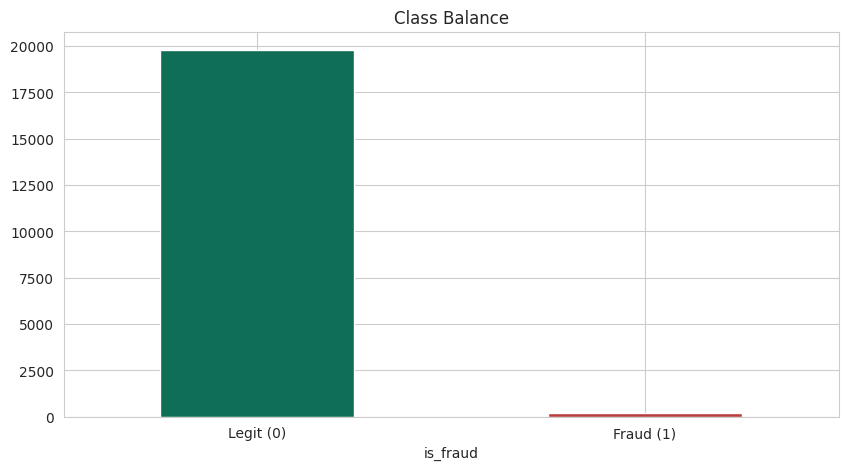

In [3]:
fraud_rate = df["is_fraud"].mean()
print(f"Fraud rate: {fraud_rate*100:.3f}%")
print(f"Fraud count: {df['is_fraud'].sum():,} / {len(df):,} total transactions")

ax = df["is_fraud"].value_counts().plot(kind="bar", color=["#0F6E56", "#BA3D3D"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
ax.set_title("Class Balance")
plt.show()


## 3. Missing values and data types

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Columns with missing values:" if len(missing_df) else "No missing values found.")
missing_df


No missing values found.


,missing_count,missing_pct


In [5]:
df.dtypes


transaction_id               str
account_id                   str
timestamp         datetime64[us]
amount                   float64
merchant                     str
country                      str
device_id                    str
is_fraud                   int64
dtype: object

## 4. Amount distribution — fraud vs legit

Fraudulent transactions often cluster at different amount ranges than legitimate ones
(either very small "card testing" amounts or unusually large amounts).

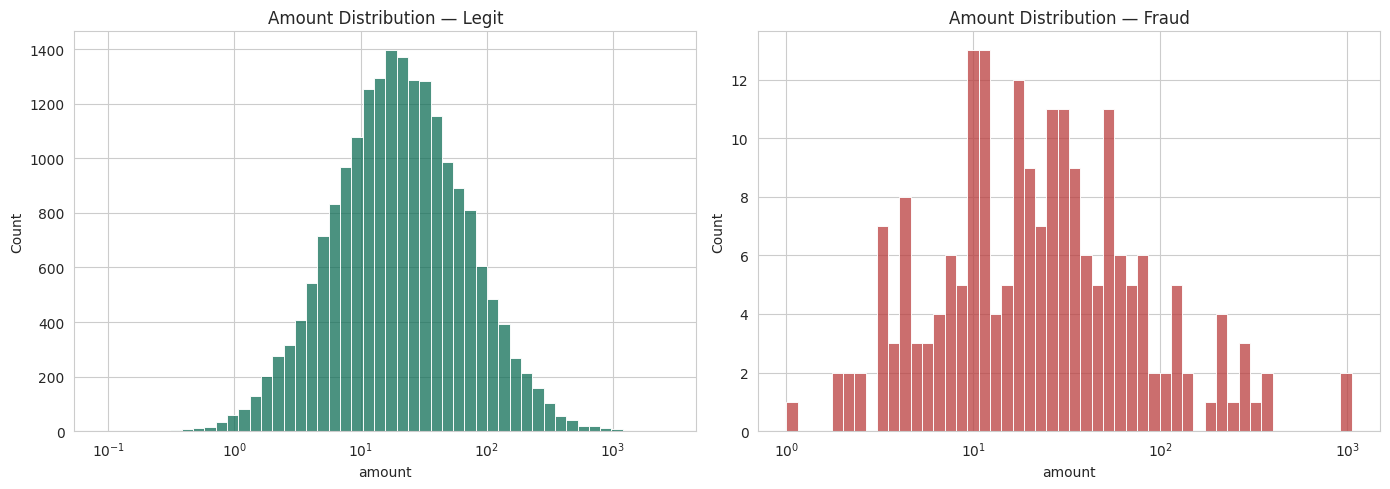

            count       mean         std   min   25%    50%     75%      max
is_fraud                                                                    
0         19796.0  41.366926   73.661221  0.09  9.05  20.08  45.190  2749.96
1           204.0  53.073235  117.683282  1.00  9.80  21.44  49.705  1055.95


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df.is_fraud == 0]["amount"], bins=50, color="#0F6E56", ax=axes[0], log_scale=True)
axes[0].set_title("Amount Distribution — Legit")

sns.histplot(df[df.is_fraud == 1]["amount"], bins=50, color="#BA3D3D", ax=axes[1], log_scale=True)
axes[1].set_title("Amount Distribution — Fraud")

plt.tight_layout()
plt.show()

print(df.groupby("is_fraud")["amount"].describe())


## 5. Time-based patterns\n\nFraud often spikes at certain hours or days. Worth checking before building time features.

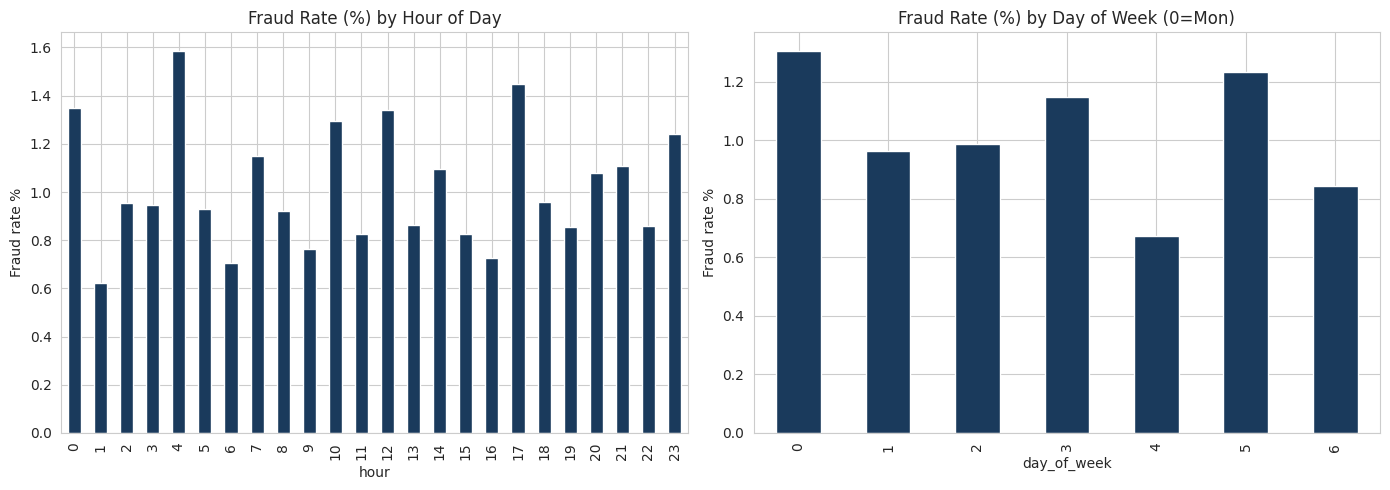

In [7]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_hour = df.groupby("hour")["is_fraud"].mean() * 100
fraud_by_hour.plot(kind="bar", color="#1A3A5C", ax=axes[0])
axes[0].set_title("Fraud Rate (%) by Hour of Day")
axes[0].set_ylabel("Fraud rate %")

fraud_by_dow = df.groupby("day_of_week")["is_fraud"].mean() * 100
fraud_by_dow.plot(kind="bar", color="#1A3A5C", ax=axes[1])
axes[1].set_title("Fraud Rate (%) by Day of Week (0=Mon)")
axes[1].set_ylabel("Fraud rate %")

plt.tight_layout()
plt.show()


## 6. Account-level transaction frequency\n\nA quick look at how many transactions each account makes — informs the velocity feature windows used in the training script.

count    500.000000
mean      40.000000
std        6.125279
min       25.000000
25%       36.000000
50%       40.000000
75%       44.000000
max       60.000000
dtype: float64


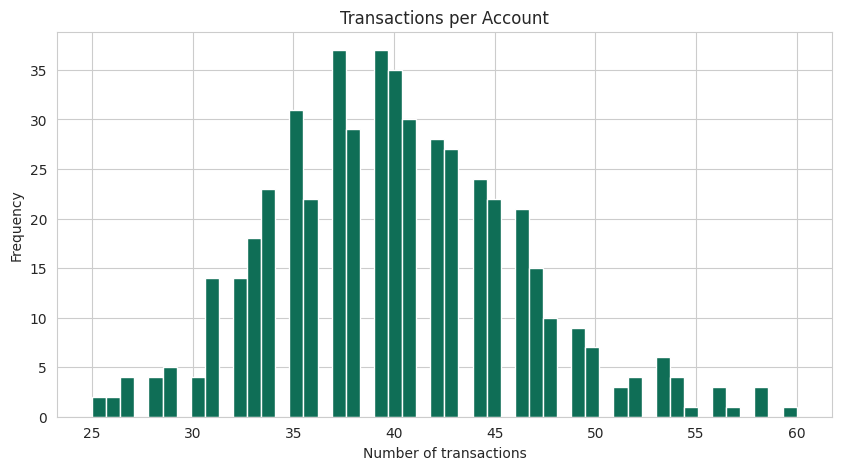

In [8]:
txn_per_account = df.groupby("account_id").size()
print(txn_per_account.describe())

ax = txn_per_account.plot(kind="hist", bins=50, color="#0F6E56")
ax.set_title("Transactions per Account")
ax.set_xlabel("Number of transactions")
plt.show()


## 7. Categorical breakdowns (merchant / country / device)

Checking if fraud concentrates in specific merchants, countries, or devices — a strong signal
if so, and informs whether frequency encoding (used in the training script) is justified.

In [9]:
for col in ["merchant", "country", "device_id"]:
    if col in df.columns:
        top_fraud_rate = df.groupby(col)["is_fraud"].agg(["mean", "count"])
        top_fraud_rate = top_fraud_rate[top_fraud_rate["count"] >= 20]  # ignore tiny samples
        top_fraud_rate = top_fraud_rate.sort_values("mean", ascending=False).head(10)
        print(f"\nTop 10 {col} by fraud rate (min 20 transactions):")
        print(top_fraud_rate)



Top 10 merchant by fraud rate (min 20 transactions):
              mean  count
merchant                 
M6        0.025641    390
M5        0.021164    378
M21       0.020619    388
M25       0.017857    448
M2        0.015345    391
M18       0.015345    391
M17       0.014851    404
M7        0.014634    410
M47       0.014354    418
M31       0.013793    435

Top 10 country by fraud rate (min 20 transactions):
             mean  count
country                 
US       0.011613   3100
UG       0.011517   9898
KE       0.009136   4050
NG       0.007642    916
UK       0.004912   2036

Top 10 device_id by fraud rate (min 20 transactions):
               mean  count
device_id                 
D87        0.064516     62
D16        0.061224     49
D149       0.058824     68
D264       0.048387     62
D68        0.048387     62
D253       0.048387     62
D113       0.047619     63
D190       0.044776     67
D244       0.044118     68
D136       0.042553     47


## 8. Correlation check (numeric features only)

Quick sanity check for obvious linear relationships before any feature engineering.

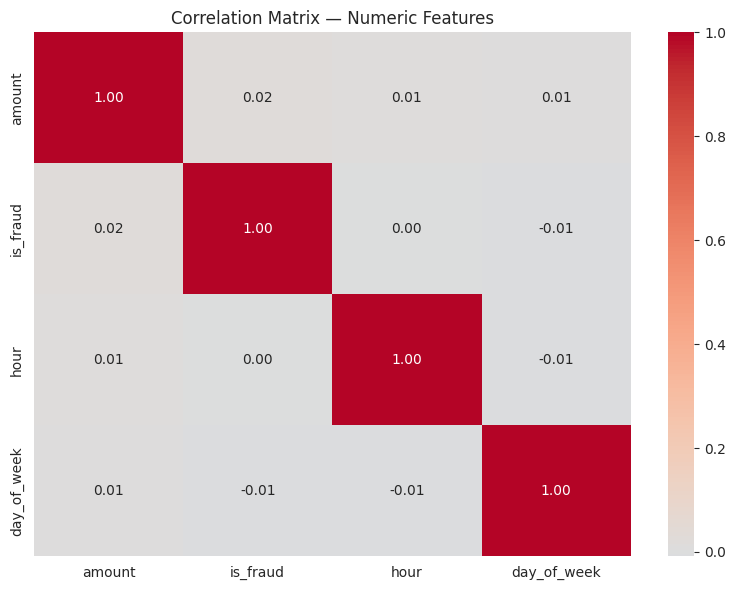

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


## 9. Findings summary

Fill this in after reviewing the plots above, e.g.:

- Fraud rate: ~X% — confirms heavy class imbalance, `scale_pos_weight` needed in training.
- Fraud transactions skew toward [higher/lower] amounts than legit ones.
- Fraud rate is elevated during [hours/days] — worth keeping `hour_of_day`/`is_night` as features.
- [Merchant/country/device] X shows disproportionately high fraud rate — frequency encoding should capture this.
- No major missing-value or data-quality issues found / [describe issues found].

**Next step:** port any new feature ideas into `src/train_fraud_model.py`'s `engineer_features()` function, then re-run training.